# B3. 크롤링 윤리와 robots.txt

| | |
|---|---|
| **트랙** | B 데이터 |
| **선수 토픽** | — |
| **프로젝트 앵커** | 도메인 화이트리스트 수집 · robots.txt fail-open 버그 발견/수정 |
| **작성일** | 2026-07-31 |
| **최종 검증** | 2026-07-31 |
| **상태** | 초안 |

## 한 줄 요약
> robots.txt 준수는 규칙을 파싱하는 문제가 아니라 규칙을 못 읽었을 때의 기본값을 정하는 문제이며, 그 기본값이 fail-open이면 배제 규칙 전체가 아무 흔적 없이 사라진다.

## 0. 준비

필요 패키지는 `numpy`, `matplotlib` 뿐이다. 네트워크 호출은 한 번도 하지 않는다.

robots.txt와 URL 목록은 §2에 **고정 스냅샷 상수**로 박아둔다. 라이브 재수집 금지 규약 때문이기도 하지만
더 큰 이유는 이 노트북의 주제가 "네트워크가 실패했을 때의 판정"이라서다. 실패를 재현하려면
네트워크가 없는 편이 오히려 낫다.

> **참고**  실제 수집 대상의 스냅샷이 `../assets/b3_robots/`에 들어오면 §2의 `ROBOTS_TXT`·`PATHS`를
> 로더로 갈아끼우고 상태를 `검증완료`로 올린다. 아래 수치는 전부 이 노트북 안의 스냅샷 기준이다.

In [1]:
# ── 표준 셋업 ────────────────────────────────────────────
from __future__ import annotations

import pathlib
import random
import re
from dataclasses import dataclass
from urllib.robotparser import RobotFileParser

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ASSETS = pathlib.Path("../assets")
OUT = pathlib.Path("./out"); OUT.mkdir(exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

# 팔레트 (FUNDAMENTAL 시리즈 공용)
C_MAIN, C_SUB, C_GRAY = "#ee4c2c", "#0d9488", "#94a3b8"

_installed = {f.name for f in fm.fontManager.ttflist}
for _f in ("AppleGothic", "Malgun Gothic", "NanumGothic"):
    if _f in _installed:
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.figsize"] = (7, 4)
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.spines.right"] = False

print(f"seed={SEED} · font={mpl.rcParams['font.family'][0]}")

seed=42 · font=NanumGothic


## 1. 개념

### robots.txt는 윤리의 전부가 아니라 가장 바깥 한 겹이다

크롤링 윤리를 한 덩어리로 보면 "robots.txt를 지켰으니 됐다"로 끝나기 쉽다. 층을 나눠 두면
자동 판정이 가능한 부분과 사람이 판단해야 하는 부분이 갈린다.

| 층 | 다루는 것 | 코드로 자동 판정 |
|---|---|---|
| robots.txt (REP) | 크롤러의 접근 범위 | 가능 |
| 이용약관·저작권 | 수집물의 재사용 범위 | 불가 |
| 서버 부하 | 요청 간격과 동시성 | 가능 |
| 개인정보 | 수집물에 섞여 들어온 식별 정보 | 부분적 |

방향은 양쪽 다 성립하지 않는다. robots.txt를 지켰다고 나머지 세 층이 면제되지 않고, 반대로
robots.txt는 접근 제어 장치도 아니다. `Disallow`는 잠금장치가 아니라 요청이며, 그 목록 자체가
숨기고 싶은 경로를 공개하는 부작용도 있다.

### 판정 규칙 — 순서가 아니라 길이

> **정의**  경로 $p$에 매치되는 규칙 집합을 $M(p)$, `Allow` 규칙 집합을 $A$라 할 때 적용 규칙과
> 최종 판정은 다음과 같다.

$$
r^\star(p) \;=\; \arg\max_{r \in M(p)} \Big(\,\big|\mathrm{pat}(r)\big|,\;
\mathbb{1}\big[r \in A\big]\,\Big),
\qquad
\mathrm{allow}(p) \;=\; \big[\,M(p) = \varnothing\,\big] \;\lor\;
\big[\,r^\star(p) \in A\,\big]
$$

즉 **패턴이 긴 규칙이 이기고, 길이가 같으면 `Allow`가 이긴다.** 파일에 적힌 줄 순서는 판정에
아무 영향을 주지 않는다. 이건 방화벽 규칙이나 `.gitignore`와 정반대 감각이라 직관을 믿으면 틀린다.

패턴 문법은 두 개뿐이다. `*`는 임의 문자열이고, 맨 뒤의 `$`는 URL 종단 앵커다. 그 외 문자는 리터럴이며
매칭은 접두사 기준이다. `User-agent` 그룹은 가장 구체적인 것 **하나만** 고르고, 여러 그룹을 합치지 않는다.
`Crawl-delay`와 `Sitemap`은 RFC 9309에 없는 확장 필드다.

### 규칙을 못 읽었을 때

여기부터가 이 노트북의 본론이다. robots.txt를 읽는 것 자체가 네트워크 요청이고, 네트워크 요청은 실패한다.

| robots.txt 응답 | RFC 9309 §2.3.1이 정하는 동작 |
|---|---|
| 2xx | 본문을 파싱해 규칙 적용 |
| 4xx | 규칙 없음으로 보고 **제한 없이 허용** |
| 5xx | 사이트 전체를 **금지**로 간주 |
| 네트워크 예외·타임아웃·파싱 실패 | 명시 없음 — 구현자가 정한다 |

마지막 줄이 비어 있다는 게 핵심이다. 규격이 비워둔 칸은 대개 구현자가 가장 편한 값으로 채우는데,
"편한 값"은 거의 언제나 수집이 계속되는 쪽, 즉 허용이다.

> **정의**  판정 불가 상황에서 허용을 기본값으로 두면 fail-open, 금지를 기본값으로 두면 fail-closed다.

> **함정**  fail-open 버그는 예외를 잡아 `True`를 돌려주는 한 줄로 만들어진다. 이 코드는 문법적으로
> 멀쩡하고, 예외 로그도 남지 않으며, 수집은 평소보다 **더 잘** 된다. 실패가 성공처럼 보이는 형태라서
> 증상만 보고는 절대 찾을 수 없다.

## 2. 최소 구현

파서 본체는 짧다. 분량의 절반은 문법이 아니라 §1 마지막 표, 즉 못 읽었을 때의 분기에 들어간다.
그 비율 자체가 이 주제의 무게중심이 어디인지를 보여준다.

먼저 패턴 매칭과 판정이다. 정의를 그대로 옮기면 `max()`의 정렬 키 한 줄이 된다.

In [2]:
@dataclass(frozen=True)
class Rule:
    """robots.txt의 규칙 한 줄. allow=False면 Disallow다."""
    allow: bool
    pattern: str


_RX_CACHE: dict[str, re.Pattern[str]] = {}


def to_regex(pattern: str) -> re.Pattern[str]:
    """`*`는 임의 문자열, 맨 뒤 `$`만 종단 앵커. 나머지는 전부 리터럴이다."""
    if pattern not in _RX_CACHE:
        anchored = pattern.endswith("$")
        body = pattern[:-1] if anchored else pattern
        rx = "".join(".*" if ch == "*" else re.escape(ch) for ch in body)
        _RX_CACHE[pattern] = re.compile("^" + rx + ("$" if anchored else ""))
    return _RX_CACHE[pattern]


def verdict(rules: list[Rule], path: str) -> tuple[bool, str]:
    """최장 매치 우선, 길이 동률이면 Allow 우선. 파일 순서는 쓰지 않는다."""
    matched = [r for r in rules if to_regex(r.pattern).match(path)]
    if not matched:
        return True, "매치 없음"
    best = max(matched, key=lambda r: (len(r.pattern), r.allow))
    return best.allow, f"{'Allow' if best.allow else 'Disallow'}: {best.pattern}"


DENY_ALL = [Rule(False, "/")]

_demo = [Rule(False, "/board/"), Rule(True, "/board/view.do")]
print("규칙 순서를 뒤집어도 판정이 같아야 한다")
print(" 원래 순서 :", verdict(_demo, "/board/view.do?id=10"))
print(" 뒤집은 순서:", verdict(_demo[::-1], "/board/view.do?id=10"))

규칙 순서를 뒤집어도 판정이 같아야 한다
 원래 순서 : (True, 'Allow: /board/view.do')
 뒤집은 순서: (True, 'Allow: /board/view.do')


다음은 이 노트북이 쓰는 고정 스냅샷 두 개다. `robots.txt`는 국내 공공기관 사이트에서 흔한 패턴을
축약해 재구성했고, `PATHS`는 수집기가 시드 페이지에서 뽑아낸 링크 목록이라고 보면 된다.

In [3]:
ROBOTS_TXT = """\
# 축약 재구성 스냅샷 — 실제 수집 대상의 robots.txt가 아니다
User-agent: *
Disallow: /admin/
Disallow: /include/
Disallow: /print/
Disallow: /search
Disallow: /download.do
Disallow: /board/
Allow: /board/view.do
Disallow: /*?
Disallow: /*.zip$
Crawl-delay: 5

User-agent: HarvesterBot
Disallow: /

Sitemap: https://www.example.or.kr/sitemap.xml
"""

AGENT = "StudyRagBot/0.1"

PATHS = """
/ /main.do /intro/greeting.do /intro/history.do /faq/list.do
/faq/view.do?id=11 /notice/list.do /board/view.do /board/view.do?id=10
/board/view.do?id=11 /board/list.do?bbsId=1 /board/attach.zip
/protection/limit.do /protection/scope.do /procedure/refund.do
/procedure/inherit.do /search.do?query=착오송금 /search/result.do
/download.do?fileId=302 /print/notice.do /admin/login.do
/include/js/app.js /data/pack.zip /data/report.pdf
""".split()

print(f"robots 라인 {len(ROBOTS_TXT.splitlines())}개 · 수집 후보 URL {len(PATHS)}개")

robots 라인 17개 · 수집 후보 URL 24개


파서는 `User-agent` 그룹을 모아 두고 그중 하나만 고른다. 연속된 `User-agent` 줄은 한 그룹으로 묶이므로
직전 줄이 무엇이었는지를 기억해야 한다.

In [4]:
def parse_robots(text: str, agent: str) -> tuple[list[Rule], float | None]:
    """robots.txt 본문에서 해당 에이전트에 적용될 규칙과 crawl-delay를 뽑는다."""
    groups: dict[str, list[tuple[str, str]]] = {}
    current: list[str] = []
    prev_was_ua = False
    for raw in text.splitlines():
        line = raw.split("#", 1)[0].strip()
        if ":" not in line:
            continue
        key, _, value = line.partition(":")
        key, value = key.strip().lower(), value.strip()
        if key == "user-agent":
            if not prev_was_ua:          # 새 그룹의 시작 — 연속 UA는 같은 그룹이다
                current = []
            current.append(value.lower())
            groups.setdefault(value.lower(), [])
            prev_was_ua = True
            continue
        prev_was_ua = False
        for ua in current:
            groups.setdefault(ua, []).append((key, value))
    low = agent.lower()
    specific = [ua for ua in groups if ua != "*" and ua in low]
    chosen = max(specific, key=len) if specific else "*"

    rules: list[Rule] = []
    delay: float | None = None
    for key, value in groups.get(chosen, []):
        if key in ("allow", "disallow") and value:
            rules.append(Rule(key == "allow", value))
        elif key == "crawl-delay":
            delay = float(value)
    return rules, delay

_rules, _delay = parse_robots(ROBOTS_TXT, AGENT)
_bad, _ = parse_robots(ROBOTS_TXT, "HarvesterBot/2.0")
print(f"{AGENT}: 규칙 {len(_rules)}개 · crawl-delay {_delay}초")
print(f"HarvesterBot/2.0: 규칙 {[r.pattern for r in _bad]}"
      f" → /main.do 판정 {verdict(_bad, '/main.do')[0]}")

StudyRagBot/0.1: 규칙 9개 · crawl-delay 5.0초
HarvesterBot/2.0: 규칙 ['/'] → /main.do 판정 False


마지막이 분기다. 상태 코드와 예외를 호출부에 흩뿌리지 않고 한 함수에 모으는 것 자체가 이 구현의
요점이다. 기본값이 인자로 드러나 있으면 fail-open을 실수로 고르기 어려워진다.

In [5]:
def policy_for(status: int | None, body: str | None, agent: str,
               *, on_error: str) -> tuple[list[Rule], str]:
    """robots.txt 응답을 규칙 목록으로 바꾼다. on_error는 'open' 또는 'closed'."""
    if status is None:                       # RFC가 비워둔 칸 — 우리가 정해야 한다
        if on_error == "open":
            return [], "예외 → 전면 허용 (fail-open)"
        return DENY_ALL, "예외 → 전면 금지 (fail-closed)"
    if 200 <= status < 300 and body is not None:
        rules, _ = parse_robots(body, agent)
        return rules, f"{status} → 규칙 {len(rules)}개 적용"
    if 400 <= status < 500:
        return [], f"{status} → 제한 없음 (RFC 9309 §2.3.1)"
    return DENY_ALL, f"{status} → 전면 금지 (RFC 9309 §2.3.1)"


for _st, _body, _mode in [(200, ROBOTS_TXT, "closed"), (404, None, "closed"),
                          (503, None, "closed"), (None, None, "open"),
                          (None, None, "closed")]:
    _r, _why = policy_for(_st, _body, AGENT, on_error=_mode)
    print(f"status={str(_st):>4} on_error={_mode:<6} → {_why}")

status= 200 on_error=closed → 200 → 규칙 9개 적용
status= 404 on_error=closed → 404 → 제한 없음 (RFC 9309 §2.3.1)
status= 503 on_error=closed → 503 → 전면 금지 (RFC 9309 §2.3.1)
status=None on_error=open   → 예외 → 전면 허용 (fail-open)
status=None on_error=closed → 예외 → 전면 금지 (fail-closed)


## 3. 프로젝트 앵커

### 우리 스택에서 이 개념이 박힌 자리

| 위치 | 내용 |
|---|---|
| 수집 범위 | 도메인 화이트리스트 — 목록에 없는 호스트는 요청 자체를 하지 않는다 |
| 배제 규칙 | 호스트별 robots.txt를 받아 경로 단위 2차 필터로 적용 |
| 코퍼스 | `assets/`의 고정 스냅샷. 노트북과 평가는 재수집하지 않는다 |
| 발견된 버그 | robots.txt 조회 실패 시 fail-open — 도메인 내 전 경로 허용 |

화이트리스트와 robots는 AND 조건이지만 작동하는 층이 다르다. 화이트리스트는 **호스트** 단위이고
robots는 **경로** 단위다. fail-open 버그가 오래 살아남은 이유가 정확히 여기 있다. 화이트리스트가
살아 있는 한 수집기는 엉뚱한 사이트로 새지 않았고, 그래서 겉으로 드러나는 증상이 없었다.
무너진 건 도메인 안쪽의 경로 필터뿐이었다.

> **함정**  fail-open의 증상은 "수집 실패"가 아니라 "수집 과다"다. 청크 수가 늘고 인덱스에 인쇄용 뷰나
> 검색 결과 페이지 같은 중복 문서가 섞인다. 이건 크롤러 로그가 아니라 B1(청킹)과 B4(stale data)
> 단계에서야 이상하게 보이기 시작한다.

> **프로젝트**  그래서 수정은 `return True`를 `return False`로 바꾸는 한 줄이 아니라, 상태 코드와 예외를
> 한 함수에 모으고 기본값을 인자로 드러내는 형태여야 한다. §2의 `policy_for()`가 그 형태이고,
> `on_error`를 생략할 수 없게 키워드 전용 인자로 둔 것도 같은 이유다.

## 4. 숫자 검증

세 가지를 잰다. 판정이 §1의 정의대로 도는가(4-1), 기본값 하나가 수집 범위를 얼마나 바꾸는가(4-2·4-3),
그리고 이 구현을 믿어도 되는가(4-4).

### 4-1. 최장 매치와 종단 앵커

기대값을 손으로 적어두고 대조한다. 특히 `/board/view.do`는 `Disallow: /board/`보다 패턴이 길어
허용으로 뒤집혀야 하는 케이스다. 표 정렬용 `wpad()`도 여기서 한 번만 정의해 §4 전체가 재사용한다.

In [6]:
def wpad(value: object, width: int, align: str = "<") -> str:
    """한글을 폭 2로 세어 자릿수를 맞춘다. §4의 표 출력이 전부 이걸 쓴다."""
    text = str(value)
    fill = " " * max(0, width - sum(2 if ord(c) > 0x2E7F else 1 for c in text))
    return fill + text if align == ">" else text + fill


CASES: list[tuple[str, bool, str]] = [
    ("/main.do",               True,  "매치 없음"),
    ("/board/view.do",         True,  "Allow(14) > Disallow /board/(7)"),
    ("/board/view.do?id=10",   True,  "쿼리가 붙어도 Allow가 최장"),
    ("/board/list.do?bbsId=1", False, "Disallow /board/(7) > /*?(3)"),
    ("/main.do?menuId=3",      False, "/*? 만 매치 — 와일드카드"),
    ("/search.do?query=x",     False, "Disallow /search(7) > /*?(3)"),
    ("/download.do?fileId=1",  False, "Disallow /download.do(13)"),
    ("/admin/login.do",        False, "접두사 매치"),
    ("/data/pack.zip",         False, "/*.zip$ — 종단 앵커"),
    ("/data/report.pdf",       True,  "매치 없음"),
]

rules, delay = parse_robots(ROBOTS_TXT, AGENT)
print(wpad("경로", 24) + wpad("기대", 7, ">") + wpad("실제", 7, ">")
      + "  " + wpad("판정", 5) + wpad("적용 규칙", 24) + "근거")
print("-" * 100)
n_pass = 0
for path, expect, note in CASES:
    got, why = verdict(rules, path)
    n_pass += got == expect
    print(wpad(path, 24) + wpad(expect, 7, ">") + wpad(got, 7, ">")
          + "  " + wpad("OK" if got == expect else "XX", 5)
          + wpad(why, 24) + note)
print(f"\n{n_pass}/{len(CASES)} 통과 · crawl-delay {delay}초")

경로                       기대   실제  판정 적용 규칙               근거
----------------------------------------------------------------------------------------------------
/main.do                   True   True  OK   매치 없음               매치 없음
/board/view.do             True   True  OK   Allow: /board/view.do   Allow(14) > Disallow /board/(7)
/board/view.do?id=10       True   True  OK   Allow: /board/view.do   쿼리가 붙어도 Allow가 최장
/board/list.do?bbsId=1    False  False  OK   Disallow: /board/       Disallow /board/(7) > /*?(3)
/main.do?menuId=3         False  False  OK   Disallow: /*?           /*? 만 매치 — 와일드카드
/search.do?query=x        False  False  OK   Disallow: /search       Disallow /search(7) > /*?(3)
/download.do?fileId=1     False  False  OK   Disallow: /download.do  Disallow /download.do(13)
/admin/login.do           False  False  OK   Disallow: /admin/       접두사 매치
/data/pack.zip            False  False  OK   Disallow: /*.zip$       /*.zip$ — 종단 앵커
/data/report.pdf           True   True  OK

### 4-2. 기본값 하나가 바꾸는 수집 범위

같은 URL 스냅샷 24개를 다섯 시나리오에 통과시킨다. 바뀌는 건 robots.txt 응답과 `on_error`뿐이고
수집기 코드도 대상 URL도 그대로다.

In [7]:
SCENARIOS: list[tuple[str, int | None, str | None, str]] = [
    ("200 정상 응답",          200,  ROBOTS_TXT, "closed"),
    ("404 robots 없음",        404,  None,       "closed"),
    ("503 서버 오류",          503,  None,       "closed"),
    ("타임아웃 · fail-open",   None, None,       "open"),
    ("타임아웃 · fail-closed", None, None,       "closed"),
]


def allowed_set(status: int | None, body: str | None, mode: str) -> set[str]:
    """해당 시나리오에서 실제로 수집될 경로 집합을 돌려준다."""
    rules, _ = policy_for(status, body, AGENT, on_error=mode)
    return {p for p in PATHS if verdict(rules, p)[0]}


results = {name: allowed_set(st, body, mode) for name, st, body, mode in SCENARIOS}
baseline = results["200 정상 응답"]

print(wpad("시나리오", 26) + wpad("허용", 8, ">") + wpad("전체", 8, ">")
      + wpad("비율", 10, ">") + wpad("200 대비", 12, ">"))
print("-" * 64)
for name in results:
    got = results[name]
    print(wpad(name, 26) + wpad(len(got), 8, ">") + wpad(len(PATHS), 8, ">")
          + wpad(f"{len(got) / len(PATHS):.3f}", 10, ">")
          + wpad(f"{len(got) - len(baseline):+d}", 12, ">"))

leaked = sorted(results["타임아웃 · fail-open"] - baseline)
print(f"\nfail-open이 추가로 통과시킨 {len(leaked)}개:")
for p in leaked:
    print("   ", p)

시나리오                      허용    전체      비율    200 대비
----------------------------------------------------------------
200 정상 응답                   14      24     0.583          +0
404 robots 없음                 24      24     1.000         +10
503 서버 오류                    0      24     0.000         -14
타임아웃 · fail-open            24      24     1.000         +10
타임아웃 · fail-closed           0      24     0.000         -14

fail-open이 추가로 통과시킨 10개:
    /admin/login.do
    /board/attach.zip
    /board/list.do?bbsId=1
    /data/pack.zip
    /download.do?fileId=302
    /faq/view.do?id=11
    /include/js/app.js
    /print/notice.do
    /search.do?query=착오송금
    /search/result.do


### 4-3. 같은 그림을 비율로

지표 축은 0~1로 고정한다. 차이가 작아 보이면 작은 것이지 축을 조여서 키울 일이 아니다.

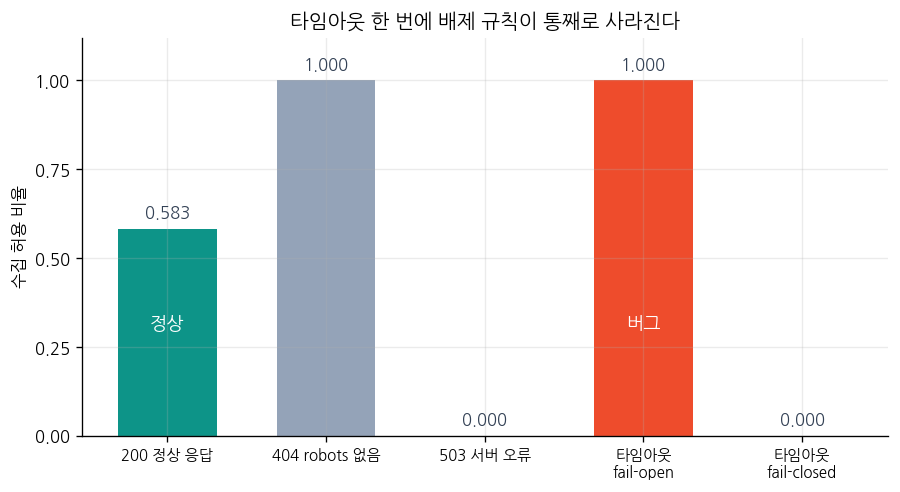

In [8]:
names = [name for name, *_ in SCENARIOS]
ratios = [len(results[n]) / len(PATHS) for n in names]
colors = [C_SUB if n.startswith("200") else
          C_MAIN if "fail-open" in n else C_GRAY for n in names]

fig, ax = plt.subplots(figsize=(7.6, 4.2))
bars = ax.bar(range(len(names)), ratios, color=colors, width=0.62)
for i, (bar, ratio) in enumerate(zip(bars, ratios)):
    ax.text(i, ratio + 0.03, f"{ratio:.3f}", ha="center", fontsize=10,
            color="#334155")

ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace(" · ", "\n") for n in names], fontsize=9)
ax.set_ylabel("수집 허용 비율")
ax.set_ylim(0, 1.12)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_title("타임아웃 한 번에 배제 규칙이 통째로 사라진다")
ax.text(3, 0.30, "버그", color="white", ha="center", fontsize=11)
ax.text(0, 0.30, "정상", color="white", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

### 4-4. 이 구현을 믿어도 되는가

직접 짠 파서를 검증 없이 쓰면 그것 자체가 다음 버그다. 표준 라이브러리 `urllib.robotparser`와
같은 스냅샷으로 대조한다.

In [9]:
rp = RobotFileParser()
rp.parse(ROBOTS_TXT.splitlines())

print(wpad("경로", 26) + wpad("우리", 8, ">") + wpad("stdlib", 10, ">") + "   비고")
print("-" * 60)
gaps = 0
for path, _expect, _note in CASES:
    ours, _ = verdict(rules, path)
    std = rp.can_fetch(AGENT, path)
    gaps += ours != std
    print(wpad(path, 26) + wpad(ours, 8, ">") + wpad(std, 10, ">")
          + ("   <- 불일치" if ours != std else ""))
print(f"\n불일치 {gaps}/{len(CASES)}건 · stdlib crawl-delay = {rp.crawl_delay(AGENT)}")

경로                          우리    stdlib   비고
------------------------------------------------------------
/main.do                      True      True
/board/view.do                True     False   <- 불일치
/board/view.do?id=10          True     False   <- 불일치
/board/list.do?bbsId=1       False     False
/main.do?menuId=3            False      True   <- 불일치
/search.do?query=x           False     False
/download.do?fileId=1        False     False
/admin/login.do              False     False
/data/pack.zip               False      True   <- 불일치
/data/report.pdf              True      True

불일치 4/10건 · stdlib crawl-delay = 5


### 결과 해석

4-1은 10/10 통과했다. 눈여겨볼 건 `/board/view.do`다. `Disallow: /board/`가 파일에서 먼저 나오는데도
허용으로 판정된다. 순서가 아니라 길이로 이긴다는 §1의 정의가 그대로 관측된 것이고, 만약 여기서
직관대로 순서 우선 구현을 했다면 게시글 본문 전체를 통째로 놓쳤을 것이다.

4-2가 이 노트북의 핵심 숫자다. 정상 응답에서는 24개 중 14개만 통과하는데, 타임아웃에 fail-open이면
24개 전부가 통과한다. **수집기 코드도 대상 URL도 바뀌지 않았고 바뀐 건 예외 처리 기본값 하나다.**
추가로 새어 들어온 10개의 성격이 특히 나쁘다. `/print/notice.do`는 본문 페이지의 중복이고,
`/search.do?query=...`는 내용이 없는 동적 페이지이며, `/include/js/app.js`는 애초에 문서가 아니다.
셋 다 청킹 단계를 그냥 통과해서 인덱스에 앉는다.

fail-closed 쪽 수치도 같이 봐야 공정하다. 타임아웃에 fail-closed면 허용은 0이다. 안전하지만
robots.txt 한 번 못 받았다고 그날 수집이 전부 멈춘다는 뜻이기도 하다. fail-closed는 공짜가 아니라
가용성을 내주고 산 값이다.

4-4의 불일치 4건은 우리 파서가 틀린 게 아니라 `urllib.robotparser`가 RFC 9309 이전 문법에
머물러 있어서 생긴다. `/main.do?menuId=3`과 `/data/pack.zip`은 stdlib이 `*`와 `$`를 리터럴로 취급해
매치 자체를 못 한 경우이고, `/board/view.do`계열 2건은 stdlib이 파일 순서 기준 최초 매치를 쓰기
때문이다. 방향이 전부 "우리는 금지, stdlib은 허용"이거나 그 반대인데, 어느 쪽이든
**stdlib을 그대로 썼다면 조용히 잘못된 범위를 수집했을 것**이다. 표준 라이브러리라는 사실이
표준 준수를 뜻하지 않는다.

## 5. 남은 질문

- fail-closed가 항상 옳은가? 대상 사이트가 5xx를 자주 뱉으면 수집이 통째로 멈춘다. Google은 캐시된
  규칙을 30일까지 재사용하는 완화책을 쓰는데, 우리 규모(호스트 소수, 수집 빈도 낮음)에서는
  "마지막 성공 규칙을 TTL과 함께 캐시하고 만료 후 fail-closed"가 맞는 절충인지.
- robots.txt를 매 요청 재조회하지 않는다면 TTL은 얼마여야 하나. 캐시가 길수록 우리 편의는 커지고
  상대의 정책 변경 반영은 늦어진다. 이 트레이드오프에 쓸 지표가 무엇인지 아직 모르겠다.
- `Crawl-delay: 5`를 곧이곧대로 지키면 수백 페이지 재수집에 수십 분이 든다. 동시 요청 1로 고정하는
  것과 호스트별로 나눠 병렬화하는 것 중 어디까지가 "부하를 주지 않는" 범위인가.
- 화이트리스트가 이미 호스트를 잠그는데 robots 체크가 중복 아닌가 — 4-2가 반례를 줬지만, 그렇다면
  경로 배제 목록을 우리가 직접 관리하는 것과 robots를 따르는 것 중 무엇이 더 견고한지.
- 이번 검증은 전부 재구성 스냅샷 기준이다. 실제 대상의 robots.txt를 넣었을 때 4-2의 12/24가
  어떻게 바뀌는지는 아직 측정하지 않았다.

## 참고

- [RFC 9309 — Robots Exclusion Protocol](https://www.rfc-editor.org/rfc/rfc9309.html) (2022 표준화,
  특히 §2.2.2 최장 매치와 §2.3.1 응답 코드 처리)
- [Google Search Central — robots.txt 사양](https://developers.google.com/search/docs/crawling-indexing/robots/robots_txt)
- CPython `Lib/urllib/robotparser.py` — 4-4 불일치의 원인
- 프로젝트: 수집 스크립트의 `policy_for` 도입 커밋, B4 stale data 노트북